# Age-Based Audience Value Clustering & Persona Prediction

This notebook implements a complete system for:
- Clustering age groups into High/Medium/Low value segments
- Calculating value scores based on conversion rate, CTR, CPC, and cost per conversion
- Recommending bid adjustments for Google Ads
- Building a prediction model for future age groups


## 1. Setup and Imports


In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Create output directories
os.makedirs('exports', exist_ok=True)
os.makedirs('reports', exist_ok=True)
os.makedirs('models', exist_ok=True)

print("✓ Environment setup complete")


✓ Environment setup complete


## 2. Configuration Parameters


In [2]:
CONFIG = {
    'min_clicks': 30,              # Small sample protection threshold
    'prior_strength': 50,          # Bayesian prior strength
    'weights': {
        'alpha': 0.5,              # Conversion rate weight
        'beta': 0.2,               # CTR weight
        'gamma': 0.15,             # CPC weight
        'delta': 0.15              # CPCV weight
    },
    'extreme_high_cpcv_multiplier': 1.8,  # Extreme high cost threshold
    'extreme_high_cr_multiplier': 1.3,    # Extreme high conversion threshold
    'n_clusters': 3,               # Number of clusters
    'random_state': 42
}

print("✓ Configuration loaded")
print(f"  Small sample protection: {CONFIG['min_clicks']} clicks")
print(f"  Prior strength: {CONFIG['prior_strength']}")
print(f"  Weights: α={CONFIG['weights']['alpha']}, β={CONFIG['weights']['beta']}, "
      f"γ={CONFIG['weights']['gamma']}, δ={CONFIG['weights']['delta']}")


✓ Configuration loaded
  Small sample protection: 30 clicks
  Prior strength: 50
  Weights: α=0.5, β=0.2, γ=0.15, δ=0.15


## 3. Load Data

Replace the sample data below with your actual age report data.


In [3]:
# Sample data (replace with actual data loading)
sample_data = {
    'age_band': ['18-24', '25-34', '35-44', '45-54', '55-64', '65+'],
    'clicks': [85, 210, 320, 450, 280, 190],
    'conversions': [1, 3, 13, 25, 20, 12],
    'impressions': [10625, 19091, 21333, 30000, 15556, 11875],
    'ctr': [0.8, 1.1, 1.5, 1.5, 1.8, 1.6],  # Percentage
    'avg_cpc': [2.10, 1.95, 1.70, 1.65, 1.55, 1.60],
    'cost': [178.50, 409.50, 544.00, 742.50, 434.00, 304.00]
}

# Create DataFrame
df = pd.DataFrame(sample_data)

# Calculate missing metrics
df['conv_rate'] = (df['conversions'] / df['clicks'] * 100).round(2)
df['cpcv'] = (df['cost'] / df['conversions']).round(2)
df.loc[df['conversions'] == 0, 'cpcv'] = np.inf

print(f"✓ Data loaded: {len(df)} age groups")
print("\nRaw data preview:")
print(df[['age_band', 'clicks', 'conversions', 'conv_rate', 'ctr', 'avg_cpc', 'cpcv']].to_string(index=False))


✓ Data loaded: 6 age groups

Raw data preview:
age_band  clicks  conversions  conv_rate  ctr  avg_cpc   cpcv
   18-24      85            1       1.18  0.8     2.10 178.50
   25-34     210            3       1.43  1.1     1.95 136.50
   35-44     320           13       4.06  1.5     1.70  41.85
   45-54     450           25       5.56  1.5     1.65  29.70
   55-64     280           20       7.14  1.8     1.55  21.70
     65+     190           12       6.32  1.6     1.60  25.33


## 4. Stage A.1: Bayesian Smoothing (Empirical Bayes)

Apply Bayesian shrinkage to handle small sample sizes and prevent overfitting to extreme values.


In [4]:
def apply_bayesian_smoothing(df, prior_strength=50):
    """Apply Bayesian shrinkage to conversion rate and CTR"""
    df = df.copy()
    
    # Calculate baselines
    base_cr = df['conversions'].sum() / df['clicks'].sum()
    base_ctr = df['clicks'].sum() / df['impressions'].sum()
    
    # Shrink conversion rate: cr_shrunk = (prior + conversions) / (prior + clicks)
    prior_conversions = prior_strength * base_cr
    prior_clicks = prior_strength
    df['cr_shrunk'] = (prior_conversions + df['conversions']) / (prior_clicks + df['clicks'])
    
    # Shrink CTR
    prior_clicks_ctr = prior_strength * base_ctr
    prior_impressions = prior_strength
    df['ctr_shrunk'] = (prior_clicks_ctr + df['clicks']) / (prior_impressions + df['impressions'])
    
    return df, base_cr, base_ctr

df, base_cr_init, base_ctr_init = apply_bayesian_smoothing(df, CONFIG['prior_strength'])

print("✓ Bayesian smoothing applied")
print(f"  Initial baseline CR: {base_cr_init:.4f} ({base_cr_init*100:.2f}%)")
print(f"  Initial baseline CTR: {base_ctr_init:.4f} ({base_ctr_init*100:.2f}%)")
print("\nShrunk conversion rates:")
print(df[['age_band', 'conv_rate', 'cr_shrunk']].to_string(index=False))


✓ Bayesian smoothing applied
  Initial baseline CR: 0.0482 (4.82%)
  Initial baseline CTR: 0.0142 (1.42%)

Shrunk conversion rates:
age_band  conv_rate  cr_shrunk
   18-24       1.18   0.025262
   25-34       1.43   0.020809
   35-44       4.06   0.041650
   45-54       5.56   0.054821
   55-64       7.14   0.067910
     65+       6.32   0.060043


## 5. Stage A.2: Calculate Baselines and Value Score

Calculate weighted baselines and compute value scores for each age group.


In [5]:
def calculate_baselines(df):
    """Calculate weighted baselines (weighted by clicks)"""
    baselines = {
        'base_cr': np.average(df['cr_shrunk'], weights=df['clicks']),
        'base_ctr': np.average(df['ctr_shrunk'], weights=df['clicks']),
        'base_cpc': np.average(df['avg_cpc'], weights=df['clicks']),
        'base_cpcv': np.average(df[df['cpcv'] != np.inf]['cpcv'], 
                                weights=df[df['cpcv'] != np.inf]['clicks'])
    }
    return baselines

def calculate_value_score(df, baselines, weights):
    """Calculate value score for each age group"""
    df = df.copy()
    
    base_cr = baselines['base_cr']
    base_ctr = baselines['base_ctr']
    base_cpc = baselines['base_cpc']
    base_cpcv = baselines['base_cpcv']
    
    # Handle infinite values
    cpcv_clean = df['cpcv'].replace([np.inf, 0], base_cpcv * 2)
    
    # Value score formula
    value_score = (
        (df['cr_shrunk'] / base_cr) ** weights['alpha'] *
        (df['ctr_shrunk'] / base_ctr) ** weights['beta'] *
        (base_cpc / df['avg_cpc']) ** weights['gamma'] *
        (base_cpcv / cpcv_clean) ** weights['delta']
    )
    
    df['value_score'] = value_score.round(4)
    
    return df

# Calculate baselines
baselines = calculate_baselines(df)
print("✓ Baselines calculated:")
print(f"  Base CR: {baselines['base_cr']:.4f} ({baselines['base_cr']*100:.2f}%)")
print(f"  Base CTR: {baselines['base_ctr']:.4f} ({baselines['base_ctr']*100:.2f}%)")
print(f"  Base CPC: ${baselines['base_cpc']:.2f}")
print(f"  Base CPCV: ${baselines['base_cpcv']:.2f}")

# Calculate value scores
df = calculate_value_score(df, baselines, CONFIG['weights'])

print("\n✓ Value scores calculated")
print("\nValue score results:")
print(df[['age_band', 'value_score', 'cr_shrunk', 'cpcv']].to_string(index=False))


✓ Baselines calculated:
  Base CR: 0.0488 (4.88%)
  Base CTR: 0.0147 (1.47%)
  Base CPC: $1.70
  Base CPCV: $53.08

✓ Value scores calculated

Value score results:
age_band  value_score  cr_shrunk   cpcv
   18-24       0.5146   0.025262 178.50
   25-34       0.5237   0.020809 136.50
   35-44       0.9608   0.041650  41.85
   45-54       1.1656   0.054821  29.70
   55-64       1.4235   0.067910  21.70
     65+       1.2714   0.060043  25.33


## 6. Stage A.3: Weighted K-Means Clustering (K=3)

Perform weighted K-means clustering to segment age groups into High/Medium/Low value clusters.


In [6]:
def perform_clustering(df, n_clusters=3, random_state=42):
    """Perform weighted K-means clustering"""
    df = df.copy()
    
    # Prepare features
    features = ['value_score', 'cr_shrunk', 'cpcv']
    feature_data = df[features].copy()
    
    # Handle infinite values
    max_cpcv = feature_data[feature_data['cpcv'] != np.inf]['cpcv'].max()
    feature_data.loc[feature_data['cpcv'] == np.inf, 'cpcv'] = max_cpcv * 2
    
    # Scale features
    scaler = StandardScaler()
    feature_data_scaled = scaler.fit_transform(feature_data)
    
    # Weighted K-means
    sample_weights = df['clicks'].values
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    clusters = kmeans.fit_predict(feature_data_scaled, sample_weight=sample_weights)
    
    df['cluster_num'] = clusters
    
    # Label clusters as H/M/L based on median value_score
    cluster_medians = df.groupby('cluster_num')['value_score'].median().sort_values(ascending=False)
    cluster_labels_map = {
        cluster_medians.index[0]: 'H',
        cluster_medians.index[1]: 'M',
        cluster_medians.index[2]: 'L'
    }
    
    df['cluster'] = df['cluster_num'].map(cluster_labels_map)
    
    return df, kmeans, scaler, cluster_labels_map

df, kmeans_model, scaler_model, cluster_map = perform_clustering(
    df, CONFIG['n_clusters'], CONFIG['random_state']
)

print("✓ Clustering completed")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())
print("\nClustering results:")
print(df[['age_band', 'value_score', 'cluster']].sort_values('value_score', ascending=False).to_string(index=False))


✓ Clustering completed

Cluster distribution:
cluster
H    3
L    2
M    1
Name: count, dtype: int64

Clustering results:
age_band  value_score cluster
   55-64       1.4235       H
     65+       1.2714       H
   45-54       1.1656       H
   35-44       0.9608       M
   25-34       0.5237       L
   18-24       0.5146       L


## 7. Stage A.4: Calculate Confidence Scores

Calculate confidence scores for cluster assignments based on distance to cluster centers and data strength.


In [7]:
def calculate_confidence(df, kmeans, scaler):
    """Calculate confidence scores for cluster assignments"""
    df = df.copy()
    
    # Prepare features
    features = ['value_score', 'cr_shrunk', 'cpcv']
    feature_data = df[features].copy()
    
    # Handle infinite values
    max_cpcv = feature_data[feature_data['cpcv'] != np.inf]['cpcv'].max()
    feature_data.loc[feature_data['cpcv'] == np.inf, 'cpcv'] = max_cpcv * 2
    
    feature_data_scaled = scaler.transform(feature_data)
    cluster_centers = kmeans.cluster_centers_
    
    confidences = []
    for idx, row in df.iterrows():
        point = feature_data_scaled[idx:idx+1]
        assigned_cluster = row['cluster_num']
        
        # Distance to assigned cluster center
        dist_to_assigned = np.linalg.norm(point - cluster_centers[assigned_cluster])
        
        # Distance to second closest cluster
        distances = [np.linalg.norm(point - center) for center in cluster_centers]
        distances_sorted = sorted(distances)
        dist_to_second = distances_sorted[1] if len(distances_sorted) > 1 else distances_sorted[0]
        
        # Cluster margin (larger margin = higher confidence)
        cluster_margin = (dist_to_second - dist_to_assigned) / (dist_to_assigned + 1e-6)
        
        # Data strength (based on clicks)
        data_strength = min(1.0, np.sqrt(row['clicks']) / 20)
        
        # Combined confidence
        confidence = min(1.0, 0.5 + 0.3 * cluster_margin + 0.2 * data_strength)
        confidences.append(confidence)
    
    df['confidence'] = np.array(confidences).round(3)
    
    return df

df = calculate_confidence(df, kmeans_model, scaler_model)

print("✓ Confidence scores calculated")
print("\nConfidence results:")
print(df[['age_band', 'cluster', 'confidence', 'clicks']].to_string(index=False))


✓ Confidence scores calculated

Confidence results:
age_band cluster  confidence  clicks
   18-24       L         1.0      85
   25-34       L         1.0     210
   35-44       M         1.0     320
   45-54       H         1.0     450
   55-64       H         1.0     280
     65+       H         1.0     190


## 8. Stage A.5: Map to Actions and Bid Modifiers

Map cluster assignments to actionable bid adjustment recommendations.


In [8]:
def map_to_actions(df, baselines, config):
    """Map cluster results to actions and bid modifiers"""
    df = df.copy()
    
    min_clicks = config['min_clicks']
    extreme_cpcv_multiplier = config['extreme_high_cpcv_multiplier']
    
    actions = []
    bid_modifiers = []
    evidences = []
    
    # Determine tiers for high value groups
    high_value_df = df[df['cluster'] == 'H'].copy()
    if len(high_value_df) > 0:
        high_value_df['tier'] = pd.qcut(
            high_value_df['value_score'],
            q=3,
            labels=['low_tier', 'mid_tier', 'top_tier'],
            duplicates='drop'
        )
        df.loc[high_value_df.index, 'tier'] = high_value_df['tier']
    
    for idx, row in df.iterrows():
        cluster = row['cluster']
        clicks = row['clicks']
        cpcv = row['cpcv']
        
        # Small sample protection
        if clicks < min_clicks:
            actions.append('keep')
            bid_modifiers.append('0%')
            evidences.append('Small sample - observe')
            continue
        
        # Generate evidence
        cr_ratio = row['cr_shrunk'] / baselines['base_cr']
        cpcv_ratio = row['cpcv'] / baselines['base_cpcv'] if row['cpcv'] != np.inf else 999
        evidence = f"CR {cr_ratio:.2f}×base; CPCV {cpcv_ratio:.2f}×base; clicks={int(clicks)}"
        
        if cluster == 'H':
            # High value - increase bids
            tier = row.get('tier', 'low_tier')
            if tier == 'top_tier':
                bid_mod = '+25%'
            elif tier == 'mid_tier':
                bid_mod = '+15%'
            else:
                bid_mod = '+10%'
            actions.append('up')
            bid_modifiers.append(bid_mod)
            evidences.append(evidence)
        
        elif cluster == 'M':
            # Medium value - keep bids
            actions.append('keep')
            bid_modifiers.append('0%')
            evidences.append(evidence)
        
        else:  # L
            # Low value - decrease bids or exclude
            if clicks >= min_clicks and cpcv >= extreme_cpcv_multiplier * baselines['base_cpcv']:
                actions.append('exclude')
                bid_modifiers.append('exclude')
                evidences.append(f"Extreme high CPCV ({cpcv:.2f} vs baseline {baselines['base_cpcv']:.2f})")
            else:
                actions.append('down')
                bid_modifiers.append('-25%')
                evidences.append(evidence)
    
    df['action'] = actions
    df['bid_modifier'] = bid_modifiers
    df['evidence'] = evidences
    
    # Clean up temporary column
    if 'tier' in df.columns:
        df = df.drop(columns=['tier'])
    
    return df

df = map_to_actions(df, baselines, CONFIG)

print("✓ Actions mapped")
print("\nAction recommendations:")
print(df[['age_band', 'cluster', 'action', 'bid_modifier', 'evidence']].to_string(index=False))


✓ Actions mapped

Action recommendations:
age_band cluster  action bid_modifier                                     evidence
   18-24       L exclude      exclude Extreme high CPCV (178.50 vs baseline 53.08)
   25-34       L exclude      exclude Extreme high CPCV (136.50 vs baseline 53.08)
   35-44       M    keep           0%     CR 0.85×base; CPCV 0.79×base; clicks=320
   45-54       H      up         +10%     CR 1.12×base; CPCV 0.56×base; clicks=450
   55-64       H      up         +25%     CR 1.39×base; CPCV 0.41×base; clicks=280
     65+       H      up         +15%     CR 1.23×base; CPCV 0.48×base; clicks=190


In [9]:
def train_rules_model(df, baselines):
    """Extract rules from clustering results"""
    base_cr = baselines['base_cr']
    base_cpcv = baselines['base_cpcv']
    
    # Extract thresholds from data
    high_value = df[df['cluster'] == 'H']
    low_value = df[df['cluster'] == 'L']
    
    if len(high_value) > 0:
        cr_high_threshold = high_value['cr_shrunk'].quantile(0.5) / base_cr
        cpcv_high_threshold = high_value[high_value['cpcv'] != np.inf]['cpcv'].quantile(0.5) / base_cpcv
    else:
        cr_high_threshold = 1.1
        cpcv_high_threshold = 0.85
    
    if len(low_value) > 0:
        cr_low_threshold = low_value['cr_shrunk'].quantile(0.5) / base_cr
        cpcv_low_threshold = low_value[low_value['cpcv'] != np.inf]['cpcv'].quantile(0.5) / base_cpcv
    else:
        cr_low_threshold = 0.9
        cpcv_low_threshold = 1.5
    
    rules = {
        'baselines': {
            'base_cr': float(baselines['base_cr']),
            'base_ctr': float(baselines['base_ctr']),
            'base_cpc': float(baselines['base_cpc']),
            'base_cpcv': float(baselines['base_cpcv'])
        },
        'high_value': {
            'cr_threshold': float(cr_high_threshold),
            'cpcv_threshold': float(cpcv_high_threshold)
        },
        'low_value': {
            'cr_threshold': float(cr_low_threshold),
            'cpcv_threshold': float(cpcv_low_threshold)
        }
    }
    
    return rules

rules_model = train_rules_model(df, baselines)

print("✓ Rules model trained")
print("\nPrediction rules:")
print(f"  High Value (H): CR >= {rules_model['high_value']['cr_threshold']:.2f}×base AND "
      f"CPCV <= {rules_model['high_value']['cpcv_threshold']:.2f}×base")
print(f"  Low Value (L): CR <= {rules_model['low_value']['cr_threshold']:.2f}×base AND "
      f"CPCV >= {rules_model['low_value']['cpcv_threshold']:.2f}×base")
print(f"  Otherwise: Medium Value (M)")

# Save rules model
with open('models/age_persona_rules.json', 'w', encoding='utf-8') as f:
    json.dump(rules_model, f, indent=2, ensure_ascii=False)

print("\n✓ Rules model saved to models/age_persona_rules.json")


✓ Rules model trained

Prediction rules:
  High Value (H): CR >= 1.23×base AND CPCV <= 0.48×base
  Low Value (L): CR <= 0.47×base AND CPCV >= 2.97×base
  Otherwise: Medium Value (M)

✓ Rules model saved to models/age_persona_rules.json


## 10. Export Results


In [10]:
# Export clustering results CSV
export_df = df[[
    'age_band', 'clicks', 'conv_rate', 'ctr', 'avg_cpc', 'cpcv',
    'value_score', 'cluster', 'confidence', 'action', 'bid_modifier', 'evidence'
]].copy()

export_df.to_csv('exports/age_clusters.csv', index=False)
print("✓ Clustering results exported to exports/age_clusters.csv")

# Export actions CSV
actions_df = df[['age_band', 'action', 'bid_modifier', 'evidence']].copy()
actions_df.columns = ['age_band', 'action', 'bid_modifier', 'rationale']
actions_df.to_csv('exports/age_actions.csv', index=False)
print("✓ Action recommendations exported to exports/age_actions.csv")

# Display formatted results
print("\n" + "="*80)
print("Final Results Preview")
print("="*80)
print("\nClustering Results:")
display_cols = ['age_band', 'clicks', 'conv_rate', 'value_score', 'cluster', 
               'confidence', 'action', 'bid_modifier']
print(df[display_cols].to_string(index=False))

print("\n\nAction Recommendations:")
print(actions_df.to_string(index=False))


✓ Clustering results exported to exports/age_clusters.csv
✓ Action recommendations exported to exports/age_actions.csv

Final Results Preview

Clustering Results:
age_band  clicks  conv_rate  value_score cluster  confidence  action bid_modifier
   18-24      85       1.18       0.5146       L         1.0 exclude      exclude
   25-34     210       1.43       0.5237       L         1.0 exclude      exclude
   35-44     320       4.06       0.9608       M         1.0    keep           0%
   45-54     450       5.56       1.1656       H         1.0      up         +10%
   55-64     280       7.14       1.4235       H         1.0      up         +25%
     65+     190       6.32       1.2714       H         1.0      up         +15%


Action Recommendations:
age_band  action bid_modifier                                    rationale
   18-24 exclude      exclude Extreme high CPCV (178.50 vs baseline 53.08)
   25-34 exclude      exclude Extreme high CPCV (136.50 vs baseline 53.08)
   35-44    

## 11. Visualization


✓ Visualization saved to reports/age_persona_analysis.png


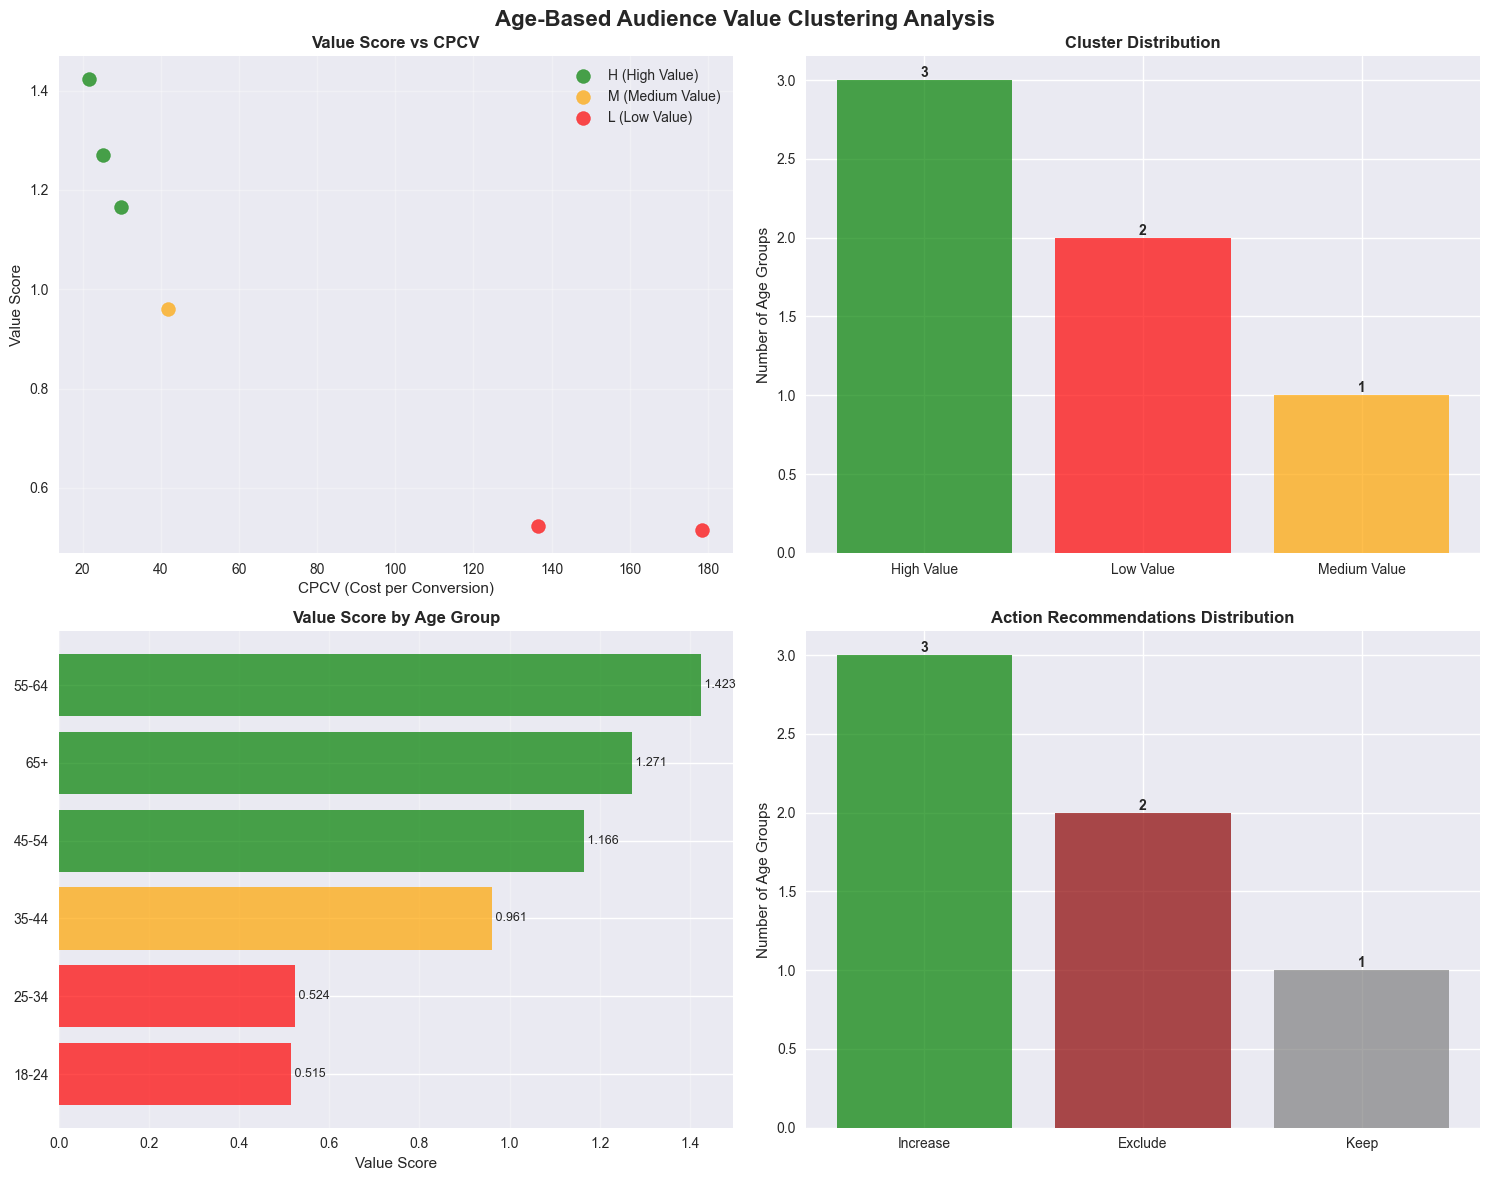

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Age-Based Audience Value Clustering Analysis', fontsize=16, fontweight='bold')

# 1. Value Score vs CPCV Scatter Plot
ax1 = axes[0, 0]
colors_map = {'H': 'green', 'M': 'orange', 'L': 'red'}
for cluster in ['H', 'M', 'L']:
    cluster_data = df[df['cluster'] == cluster]
    cpcv_clean = cluster_data['cpcv'].replace([np.inf, 0], baselines['base_cpcv'] * 2)
    ax1.scatter(cpcv_clean, cluster_data['value_score'], 
               label=f'{cluster} ({"High" if cluster=="H" else "Medium" if cluster=="M" else "Low"} Value)',
               color=colors_map[cluster], s=100, alpha=0.7)
ax1.set_xlabel('CPCV (Cost per Conversion)', fontsize=11)
ax1.set_ylabel('Value Score', fontsize=11)
ax1.set_title('Value Score vs CPCV', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Cluster Distribution
ax2 = axes[0, 1]
cluster_counts = df['cluster'].value_counts().sort_index()
cluster_labels = {'H': 'High Value', 'M': 'Medium Value', 'L': 'Low Value'}
colors_list = [colors_map[c] for c in cluster_counts.index]
bars = ax2.bar([cluster_labels[c] for c in cluster_counts.index], 
               cluster_counts.values, color=colors_list, alpha=0.7)
ax2.set_ylabel('Number of Age Groups', fontsize=11)
ax2.set_title('Cluster Distribution', fontsize=12, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 3. Value Score by Age Group
ax3 = axes[1, 0]
df_sorted = df.sort_values('value_score', ascending=True)
colors_list_sorted = [colors_map[c] for c in df_sorted['cluster']]
bars = ax3.barh(df_sorted['age_band'], df_sorted['value_score'], color=colors_list_sorted, alpha=0.7)
ax3.set_xlabel('Value Score', fontsize=11)
ax3.set_title('Value Score by Age Group', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
for i, (bar, score) in enumerate(zip(bars, df_sorted['value_score'])):
    ax3.text(score, i, f' {score:.3f}', va='center', fontsize=9)

# 4. Action Recommendations
ax4 = axes[1, 1]
action_counts = df['action'].value_counts()
action_labels_map = {'up': 'Increase', 'down': 'Decrease', 'keep': 'Keep', 'exclude': 'Exclude'}
action_colors = {'up': 'green', 'down': 'red', 'keep': 'gray', 'exclude': 'darkred'}
colors_list_actions = [action_colors.get(a, 'blue') for a in action_counts.index]
bars = ax4.bar([action_labels_map.get(a, a) for a in action_counts.index], 
               action_counts.values, color=colors_list_actions, alpha=0.7)
ax4.set_ylabel('Number of Age Groups', fontsize=11)
ax4.set_title('Action Recommendations Distribution', fontsize=12, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/age_persona_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Visualization saved to reports/age_persona_analysis.png")
plt.show()


## 12. Summary Report


In [12]:
print("="*80)
print("Age-Based Audience Value Clustering Analysis - Final Report")
print("="*80)

print(f"\n📊 Baseline Metrics:")
print(f"  Conversion Rate (CR): {baselines['base_cr']:.4f} ({baselines['base_cr']*100:.2f}%)")
print(f"  Click-Through Rate (CTR): {baselines['base_ctr']:.4f} ({baselines['base_ctr']*100:.2f}%)")
print(f"  Average CPC: ${baselines['base_cpc']:.2f}")
print(f"  Cost per Conversion (CPCV): ${baselines['base_cpcv']:.2f}")

print(f"\n🎯 Clustering Results:")
cluster_summary = df.groupby('cluster').agg({
    'age_band': 'count',
    'clicks': 'sum',
    'conversions': 'sum',
    'cost': 'sum',
    'value_score': 'mean'
}).round(2)
cluster_summary.columns = ['Age Groups', 'Total Clicks', 'Total Conversions', 'Total Cost', 'Avg Value Score']
print(cluster_summary)

print(f"\n⚡ Action Recommendations Summary:")
action_summary = df.groupby('action').agg({
    'age_band': 'count',
    'clicks': 'sum',
    'cost': 'sum'
}).round(2)
action_summary.columns = ['Age Groups', 'Total Clicks', 'Total Cost']
print(action_summary)

print(f"\n📈 Top 3 Recommendations:")
top_recommendations = df.nlargest(3, 'value_score')[['age_band', 'action', 'bid_modifier', 'evidence']]
for idx, row in top_recommendations.iterrows():
    print(f"  {row['age_band']}: {row['action']} {row['bid_modifier']} - {row['evidence']}")

print(f"\n📁 Output Files:")
print(f"  ✓ exports/age_clusters.csv - Complete clustering results")
print(f"  ✓ exports/age_actions.csv - Action recommendations")
print(f"  ✓ models/age_persona_rules.json - Prediction rules model")
print(f"  ✓ reports/age_persona_analysis.png - Visualization charts")

print("\n" + "="*80)
print("Analysis Complete!")
print("="*80)


Age-Based Audience Value Clustering Analysis - Final Report

📊 Baseline Metrics:
  Conversion Rate (CR): 0.0488 (4.88%)
  Click-Through Rate (CTR): 0.0147 (1.47%)
  Average CPC: $1.70
  Cost per Conversion (CPCV): $53.08

🎯 Clustering Results:
         Age Groups  Total Clicks  Total Conversions  Total Cost  \
cluster                                                            
H                 3           920                 57      1480.5   
L                 2           295                  4       588.0   
M                 1           320                 13       544.0   

         Avg Value Score  
cluster                   
H                   1.29  
L                   0.52  
M                   0.96  

⚡ Action Recommendations Summary:
         Age Groups  Total Clicks  Total Cost
action                                       
exclude           2           295       588.0
keep              1           320       544.0
up                3           920      1480.5

📈 Top 3 Recomm